# preprocessing

In [2]:
import pandas as pd
import json

In [13]:
datasets_paths = {
    "linkedin": "../extractor/linkedin_translated_skills.jsonl",
    "alljobs": "../extractor/alljobs_translated_skills.jsonl"
}

In [4]:
def clean_skill_data(item):
    """Extracts and cleans skills from the nested JSON structure."""
    all_matches = item['skills'].get('full_matches', []) + item['skills'].get('ngram_matches', [])
    skills = [m['doc_node_value'].lower() for m in all_matches]
    
    noise = ['com', 'job description', 'product name', 'brand names']
    clean = [s for s in skills if len(s) > 2 and s not in noise]
    return list(set(clean))

In [19]:
def process_dataset_file(dataset_source, dataset_path):
    processed_records = []
    with open(dataset_path, 'r', encoding='utf-8') as f:
        for line in f:
            try:
                item = json.loads(line)
                title = item.get('title', 'Unknown Title')
                query_title = item.get('og_title')

                # scarping typo
                if not query_title:
                    query_title = item.get('og_tite')
                    
                skills = clean_skill_data(item)
                if skills:
                    processed_records.append({
                    'query_title': query_title,
                    'title': title,
                    'skills': skills,
                    'source': dataset_source
                })
            except json.JSONDecodeError:
                continue


    return pd.DataFrame(processed_records)

In [20]:
datasets_dfs = []
for dataset_source, dataset_file in datasets_paths.items():
    datasets_dfs.append(process_dataset_file(dataset_source, dataset_file))

df = pd.concat(datasets_dfs, ignore_index=True)

In [21]:
df.head()

,query_title,title,skills,source
0,SOC Analyst,SOC Analyst Tier 2 (1005527),"[phishing, customer experience, cyber incident...",linkedin
1,SOC Analyst,Security Operations Center Analyst,"[problem solve, analytical, time management, t...",linkedin
2,SOC Analyst,SOC Analyst,"[siem, endpoint security, phishing, persistenc...",linkedin
3,SOC Analyst,Soc Analyst,"[draws, problem solve, auditing, operation, se...",linkedin
4,SOC Analyst,Security Operations Center Analyst,[splunk],linkedin


In [22]:
df.shape

(8486, 4)

In [23]:
print(df.describe)

<bound method NDFrame.describe of                                    query_title  \
0                                  SOC Analyst   
1                                  SOC Analyst   
2                                  SOC Analyst   
3                                  SOC Analyst   
4                                  SOC Analyst   
...                                        ...   
8481  Security Researcher (Mobile/Android/iOS)   
8482  Security Researcher (Mobile/Android/iOS)   
8483  Security Researcher (Mobile/Android/iOS)   
8484  Security Researcher (Mobile/Android/iOS)   
8485  Security Researcher (Mobile/Android/iOS)   

                                         title  \
0                 SOC Analyst Tier 2 (1005527)   
1           Security Operations Center Analyst   
2                                  SOC Analyst   
3                                  Soc Analyst   
4           Security Operations Center Analyst   
...                                        ...   
8481  לארגון פי

In [72]:
df["title"].unique()

array(['SOC Analyst Tier 2 (1005527)',
       'Security Operations Center Analyst', 'SOC Analyst', ...,
       'מנתח /ת מערכות דיגיטל', 'דרוש /ה מפתח /ת אפליקציות Native IOS',
       'Mobile Growth Account Manager'], shape=(4727,), dtype=object)

In [12]:
df['title'].value_counts()

title
DevOps Engineer                             114
Product Manager                              95
Senior Backend Developer                     84
Software Engineer                            66
Data Engineer                                66
                                           ... 
Marketing Operations Manager                  1
Trading Operations Specialist- Part time      1
Operations Manager, Middle East               1
HR Operations Manager                         1
Mobile Growth Account Manager                 1
Name: count, Length: 4727, dtype: int64

# EDA

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

In [ ]:
POC_TITLES = ['Software Engineer', 'Data Scientist', 'Product Manager', 'DevOps Engineer', 'Frontend Developer']

# Filter by query_title (og_title) — captures ALL postings for each role,
# not just the ones with an exact title match
sample_df = df[df["query_title"].isin(POC_TITLES)].copy()

print(f"sample_df: {len(sample_df)} records across {sample_df['query_title'].nunique()} roles")
print(sample_df["query_title"].value_counts())

In [32]:
sample_df.shape

(230, 4)

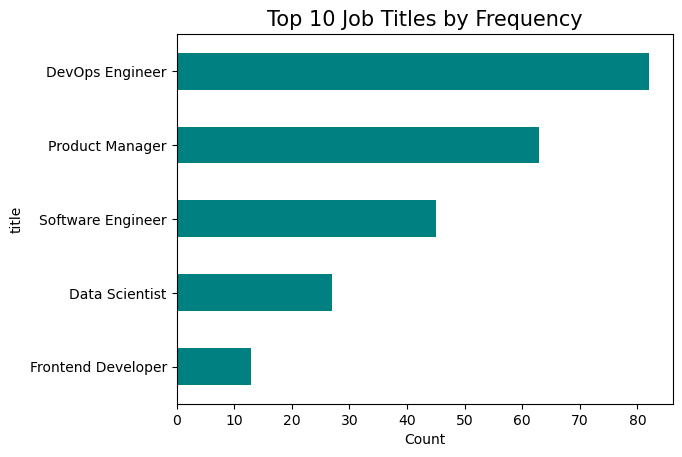

In [33]:
plt.figure()
sample_df['title'].value_counts().head(10).plot(kind='barh', color='teal')
plt.title('Top 10 Job Titles by Frequency', fontsize=15)
plt.xlabel('Count')
plt.gca().invert_yaxis() # Highest on top
plt.show()

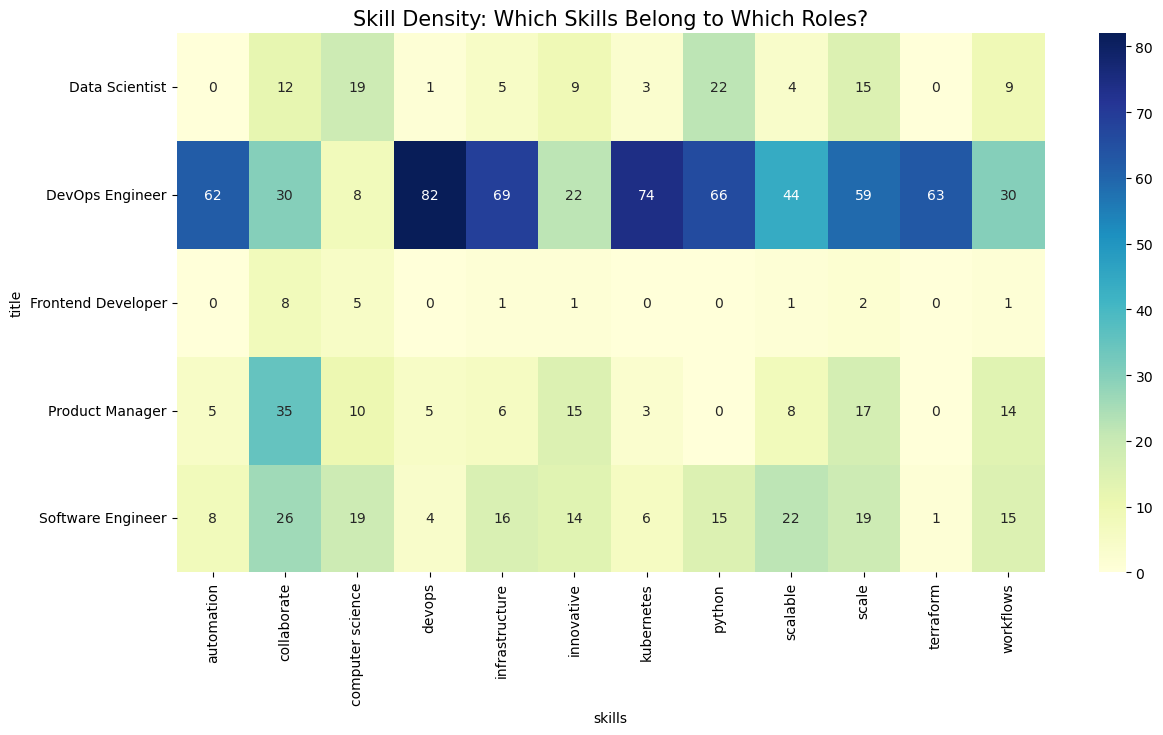

In [34]:
df_exploded = sample_df.explode('skills')
top_titles = sample_df['title'].value_counts().nlargest(5).index
top_skills = df_exploded['skills'].value_counts().nlargest(12).index

# Filter and create frequency table
heatmap_data = df_exploded[
    df_exploded['title'].isin(top_titles) & 
    df_exploded['skills'].isin(top_skills)
]
pivot_table = heatmap_data.pivot_table(index='title', columns='skills', aggfunc='size', fill_value=0)

plt.figure(figsize=(14, 7))
sns.heatmap(pivot_table, annot=True, cmap='YlGnBu', fmt='d')
plt.title('Skill Density: Which Skills Belong to Which Roles?', fontsize=15)
plt.show()

In [ ]:
def plot_skill_rank_for_title(df, target_title, min_appearance=2):
    """
    Plots the most frequent skills for a canonical role (query_title),
    showing both raw frequency and prevalence % across postings.
    """
    # Filter by query_title — covers all posting variants for this role
    subset = df[df['query_title'].str.lower() == target_title.lower()]

    if subset.empty:
        print(f"No data found for role: {target_title}")
        return

    total_postings = len(subset)
    all_skills = [skill for sublist in subset['skills'] for skill in sublist]
    skill_counts = Counter(all_skills)

    rank_df = pd.DataFrame(skill_counts.items(), columns=['Skill', 'Frequency'])
    rank_df['Prevalence'] = (rank_df['Frequency'] / total_postings * 100).round(1)
    rank_df = rank_df[rank_df['Frequency'] >= min_appearance]
    rank_df = rank_df.sort_values(by='Frequency', ascending=False).head(20)

    if rank_df.empty:
        print(f"No skills meet the minimum frequency of {min_appearance} for {target_title}")
        return

    fig, ax = plt.subplots(figsize=(10, len(rank_df) * 0.45))
    bars = ax.barh(rank_df['Skill'], rank_df['Frequency'], color='steelblue')

    # Annotate with prevalence %
    for bar, pct in zip(bars, rank_df['Prevalence']):
        ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
                f'{pct}%', va='center', fontsize=9, color='dimgray')

    ax.invert_yaxis()
    ax.set_title(f'Top Skills: {target_title}\n({total_postings} postings)', fontsize=14)
    ax.set_xlabel('Times Appeared')
    ax.grid(axis='x', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()

In [ ]:
for title in POC_TITLES:
    plot_skill_rank_for_title(sample_df, title)

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd

sample_titles = [
    "Senior Data Analyst",
    "Security Analyst",
    "Product Manager"
]

# Character N-Grams — fixes 'scale/scalable' fuzzy matching issues
tfidf = TfidfVectorizer(analyzer='char_wb', ngram_range=(3, 4))
X = tfidf.fit_transform(sample_titles)

feature_names = tfidf.get_feature_names_out()
vector_df = pd.DataFrame(X.toarray(), columns=feature_names, index=sample_titles)

print("Top Feature Chunks for 'Senior Data Analyst':")
print(vector_df.loc[["Senior Data Analyst"]].T.sort_values(by="Senior Data Analyst", ascending=False).head(10))

/var/folders/3g/791ws3zd2s92ygwrz3jxf8q00000gn/T/ipykernel_74101/3055616974.py:37: UserWarning: Glyph 128272 (\N{CLOSED LOCK WITH KEY}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/opt/anaconda3/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128272 (\N{CLOSED LOCK WITH KEY}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


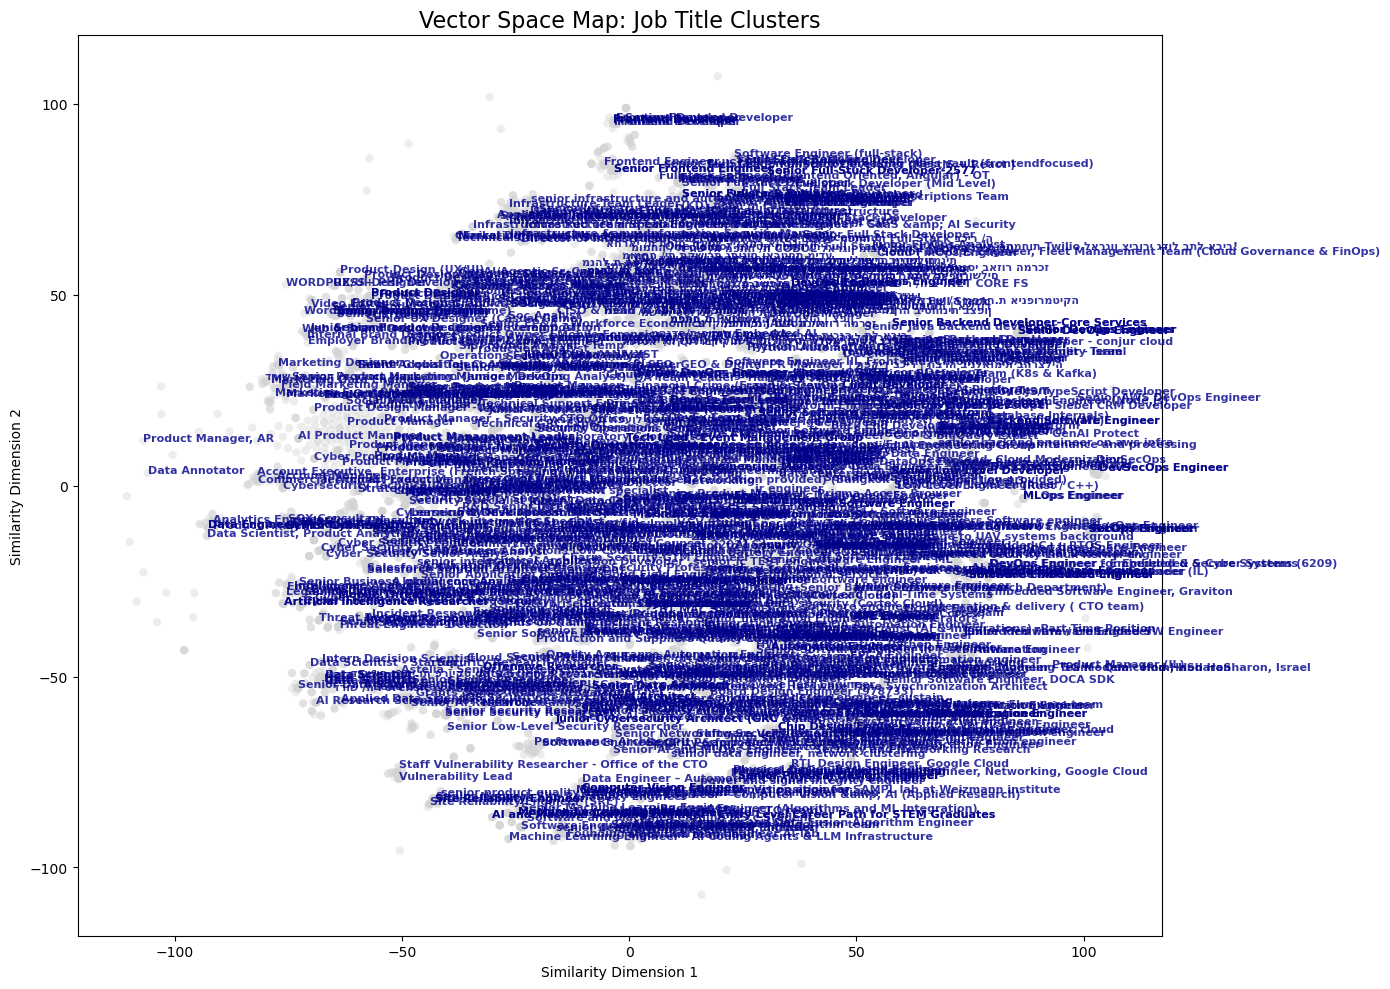

In [48]:
from sklearn.manifold import TSNE
from sklearn.feature_extraction.text import TfidfVectorizer 
import matplotlib.pyplot as plt
import numpy as np

tfidf = TfidfVectorizer(analyzer='char_wb', ngram_range=(3, 4))
# 1. Vectorize the titles
X_full = tfidf.fit_transform(df['title'])

# 2. Run t-SNE
# Perplexity should be smaller than the number of samples
tsne = TSNE(n_components=2, perplexity=min(30, len(df)-1), random_state=42)
X_embedded = tsne.fit_transform(X_full.toarray())

# 3. Plotting
plt.figure(figsize=(14, 10))
plt.scatter(X_embedded[:, 0], X_embedded[:, 1], alpha=0.4, c='lightgrey', edgecolors='none')

# 4. Adding Labels (The "Magic" part)
# To avoid a mess, we will label a subset of points
# You can change this to label every 5th point, or just the top 20 points
for i in range(len(df)):
    # Example logic: label every 5th title to keep it clean
    if i % 10 == 0:
        plt.annotate(
            df['title'].iloc[i], 
            (X_embedded[i, 0], X_embedded[i, 1]),
            fontsize=8,
            alpha=0.8,
            color='darkblue',
            weight='semibold'
        )

plt.title("Vector Space Map: Job Title Clusters", fontsize=16)
plt.xlabel("Similarity Dimension 1")
plt.ylabel("Similarity Dimension 2")
plt.tight_layout()
plt.show()

In [ ]:
import plotly.express as px
import webbrowser, os

plot_df = pd.DataFrame({
    'x': X_embedded[:, 0],
    'y': X_embedded[:, 1],
    'title': df['title']
})

fig = px.scatter(plot_df, x='x', y='y', hover_name='title',
                width=1200, height=1000,
                title="Interactive Job Title Map (Hover to see titles)")

out = r'c:\Git\CareerLens\ds\model\tsne_map.html'
fig.write_html(out)
webbrowser.open(f'file:///{out}')
print(f"Saved to {out}")

# Train

In [ ]:
import json
import os
from collections import defaultdict
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.neighbors import NearestNeighbors

POC_TITLE_VARIANTS = {
    "Software Engineer": [
        "Software Engineer",
        "Senior Software Engineer",
        "Backend Engineer",
        "Senior Backend Engineer",
        "Backend Software Engineer",
        "Full Stack Engineer",
        "Senior Full Stack Engineer",
        "SW Engineer",
        "Senior SW Engineer",
        "Staff Software Engineer",
        "Junior Software Engineer",
        "Python Developer",
        "ML Engineer",
    ],
    "Data Scientist": [
        "Data Scientist",
        "Senior Data Scientist",
    ],
    "Product Manager": [
        "Product Manager",
        "Senior Product Manager",
        "Group Product Manager",
        "Product Owner",
        "Technical Product Manager",
        "Associate Product Manager",
    ],
    "DevOps Engineer": [
        "DevOps Engineer",
        "Senior DevOps Engineer",
        "Cloud Engineer",
        "Site Reliability Engineer",
        "SRE",
        "Infrastructure Engineer",
        "Azure DevOps Engineer",
        "Junior DevOps Engineer",
    ],
    "Frontend Developer": [
        "Frontend Developer",
        "Senior Frontend Developer",
        "Frontend Engineer",
        "Senior Frontend Engineer",
        "React Developer",
        "UI Developer",
        "UI Engineer",
        "Web Developer",
    ],
}

POC_TITLES = list(POC_TITLE_VARIANTS.keys())

# Reverse lookup: variant title (lowercase) -> canonical title
VARIANT_TO_CANONICAL = {
    variant.lower(): canonical
    for canonical, variants in POC_TITLE_VARIANTS.items()
    for variant in variants
}

datasets_paths = {
    "linkedin": "../extractor/linkedin_translated_skills.jsonl",
    "alljobs":  "../extractor/alljobs_translated_skills.jsonl"
}

# ── Normalization constants ───────────────────────────────────────────────────

# All POC role name forms — must never appear as a skill in any role
ROLE_NAME_NOISE = {
    'software engineer', 'software engineers', 'software engineering',
    'data scientist', 'data scientists',
    'product manager', 'product managers', 'product management',
    'devops engineer', 'devops',
    'frontend developer', 'frontend developers',
}

# Skills that appear across ALL roles — carry zero discriminative signal
UNIVERSAL_NOISE = {
    'scale', 'scalable', 'scalability',
    'collaborate', 'collaborates', 'collaboration', 'collaborations',
    'communication', 'communications', 'communication skills',
    'best practices', 'best practice',
    'leadership', 'reliability', 'research',
    'track', 'translate', 'innovative', 'innovation', 'innovations',
    'workflow', 'workflows', 'computer science',
    'problem solve', 'problem solving',
    'management', 'manage', 'english', 'nice', 'plan', 'act', 'eye',
    'com', 'job description', 'product name', 'brand names',
} | ROLE_NAME_NOISE

# Common singular/plural pairs — merge into the canonical form
SKILL_NORMALIZE = {
    'algorithms':    'algorithm',
    'integrations':  'integration',
    'operations':    'operation',
    'systems':       'system',
    'platforms':     'platform',
    'pipelines':     'pipeline',
    'services':      'service',
    'frameworks':    'framework',
    'databases':     'database',
    'technologies':  'technology',
    'environments':  'environment',
    'deployments':   'deployment',
    'applications':  'application',
    'solutions':     'solution',
    'requirements':  'requirement',
    'components':    'component',
    'repositories':  'repository',
    'features':      'feature',
    'microservices': 'microservice',
    'containers':    'container',
}

# ── Helpers ───────────────────────────────────────────────────────────────────

def normalize_skill(sk):
    sk = sk.lower().strip()
    return SKILL_NORMALIZE.get(sk, sk)

def is_valid_skill(sk, canonical):
    if len(sk) < 3:                          # too short
        return False
    if sk in UNIVERSAL_NOISE:                # generic or role-name leak
        return False
    if canonical.lower() in sk:              # role name substring
        return False
    role_tokens = set(canonical.lower().split())
    if sk in role_tokens:                    # individual role word
        return False
    return True

def resolve_canonical(og_title, actual_title):
    if og_title in POC_TITLES:
        return og_title
    if actual_title and actual_title.lower() in VARIANT_TO_CANONICAL:
        return VARIANT_TO_CANONICAL[actual_title.lower()]
    return None

def extract_weighted_skills(item, canonical):
    full_raw = {m['doc_node_value'].lower() for m in item['skills'].get('full_matches', [])}
    scores = defaultdict(float)

    for sk in full_raw:
        sk = normalize_skill(sk)
        if is_valid_skill(sk, canonical):
            scores[sk] += 1.0

    for m in item['skills'].get('ngram_matches', []):
        sk_raw = m['doc_node_value'].lower()
        if sk_raw in full_raw:
            continue
        score = m.get('score', 0.5)
        if score < 0.75:
            continue
        sk = normalize_skill(sk_raw)
        if is_valid_skill(sk, canonical):
            scores[sk] += score

    return dict(scores)

# ── Load & aggregate ──────────────────────────────────────────────────────────

role_skill_scores = {title: defaultdict(float) for title in POC_TITLES}
record_counts     = defaultdict(int)
source_counts     = defaultdict(lambda: defaultdict(int))

for source, path in datasets_paths.items():
    with open(path, 'r', encoding='utf-8') as f:
        for line in f:
            try:
                item = json.loads(line)
                og_title     = item.get('og_title') or item.get('og_tite')
                actual_title = item.get('title', '')

                canonical = resolve_canonical(og_title, actual_title)
                if canonical is None:
                    continue

                total_skills = (len(item['skills'].get('full_matches', [])) +
                                len(item['skills'].get('ngram_matches', [])))
                if total_skills < 5:
                    continue

                weighted = extract_weighted_skills(item, canonical)
                if not weighted:
                    continue

                for skill, score in weighted.items():
                    role_skill_scores[canonical][skill] += score
                record_counts[canonical] += 1

                match_src = 'og_title' if og_title == canonical else 'actual_title'
                source_counts[canonical][match_src] += 1

            except json.JSONDecodeError:
                continue

print("Records loaded per role:")
for title in POC_TITLES:
    og     = source_counts[title]['og_title']
    actual = source_counts[title]['actual_title']
    print(f"  {title}: {record_counts[title]} postings "
          f"(og_title: {og} | actual_title: {actual}), "
          f"{len(role_skill_scores[title])} unique skills")

# ── Sort skills by prevalence (score / n_postings) ───────────────────────────

role_sorted_skills = {}
for title in POC_TITLES:
    n = record_counts[title]
    role_sorted_skills[title] = [
        skill for skill, score in
        sorted(role_skill_scores[title].items(), key=lambda x: -x[1] / n)
    ]

# ── Build KNN on variant titles ───────────────────────────────────────────────

variant_titles = []
variant_labels = []

for canonical, variants in POC_TITLE_VARIANTS.items():
    for v in variants:
        variant_titles.append(v)
        variant_labels.append(canonical)

skills_data = [role_sorted_skills[label] for label in variant_labels]

vectorizer = TfidfVectorizer(analyzer='char_wb', ngram_range=(2, 4))
X = vectorizer.fit_transform(variant_titles)

knn = NearestNeighbors(n_neighbors=1, metric='cosine')
knn.fit(X)

print(f"\nKNN trained on {len(variant_titles)} variant titles, {X.shape[1]} features")

In [ ]:
def get_top_skills(input_title, n=10):
    vec = vectorizer.transform([input_title])
    _, indices = knn.kneighbors(vec)
    idx = indices[0][0]
    matched_variant = variant_titles[idx]
    matched_role = variant_labels[idx]
    top_skills = skills_data[idx][:n]
    return matched_variant, matched_role, top_skills

test_inputs = [
    "Senior Software Engineer",
    "Python Developer",
    "React Developer",
    "ML Engineer",
    "Cloud Architect",
    "Scrum Master",
    "Junior DevOps",
    "Data Analyst",
    "Tech Lead",
    "UI/UX Designer",
]

print("Inference results:")
for title in test_inputs:
    variant, role, skills = get_top_skills(title, n=5)
    print(f"\n  '{title}'")
    print(f"    -> matched variant : '{variant}'")
    print(f"    -> canonical role  : [{role}]")
    print(f"    -> top 5 skills    : {skills}")

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

# ── Prevalence % visualization — top 15 skills per canonical role ─────────────
fig = plt.figure(figsize=(18, 14))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.55, wspace=0.4)
axes = [fig.add_subplot(gs[i // 3, i % 3]) for i in range(len(POC_TITLES))]

for ax, title in zip(axes, POC_TITLES):
    n   = record_counts[title]
    top = sorted(role_skill_scores[title].items(), key=lambda x: -x[1] / n)[:15]
    skills     = [s for s, _ in top]
    prevalence = [round(sc / n * 100, 1) for _, sc in top]

    bars = ax.barh(skills[::-1], prevalence[::-1], color='steelblue')
    for bar, pct in zip(bars, prevalence[::-1]):
        ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height() / 2,
                f'{pct}%', va='center', fontsize=8, color='dimgray')

    ax.set_title(f'{title}\n({n} postings)', fontsize=11, fontweight='bold')
    ax.set_xlabel('Prevalence %')
    ax.set_xlim(0, max(prevalence) * 1.25)
    ax.grid(axis='x', linestyle='--', alpha=0.4)

# Hide unused subplot (5 roles, 6 slots)
fig.delaxes(fig.axes[-1])
fig.suptitle('Top 15 Skills by Prevalence — POC Roles', fontsize=15, fontweight='bold')
plt.show()

In [ ]:
import joblib
from datetime import datetime

timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

model_artifacts = {
    'vectorizer':      vectorizer,
    'knn_model':       knn,
    'skills':          skills_data,
    'titles':          variant_labels,
    'variant_titles':  variant_titles,
    'trained_at':      timestamp,
}

base = r'c:\Git\CareerLens\ds\model'

# Timestamped version — for history
versioned_path = f'{base}\\model_{timestamp}.joblib'
joblib.dump(model_artifacts, versioned_path)

# Latest — what server.py loads
latest_path = f'{base}\\model.joblib'
joblib.dump(model_artifacts, latest_path)

print(f"Trained at : {timestamp}")
print(f"Versioned  : {versioned_path}")
print(f"Latest     : {latest_path}")
print(f"\nTop 5 skills per canonical role:")
for title in POC_TITLES:
    idx = variant_labels.index(title)
    print(f"  {title}: {skills_data[idx][:5]}")